In [21]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# So that we can edit the text in illustrator
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
fig_out_dir = Path("final_figures/figure_4")
fig_out_dir.mkdir(exist_ok=True, parents=True)


import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

In [22]:
fig_out_dir = Path("final_figures/figure_4")
fig_out_dir.mkdir(exist_ok=True, parents=True)

## Get participant data for current pipeline

In [23]:
#### Load in experiment manifests with full transcripts
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_part_meta_dict(meta_file_name):
    part_manifest = pd.read_pickle(meta_file_name)
    records = []
    trial_ix_count = 0 
    for block_ix, (block_name, block) in enumerate(part_manifest.items()):
        if isinstance(block, dict):
            for trial_ix, trial_dict in block.items():
                trial_dict['trial_num'] = trial_ix_count
                trial_dict['target_azimuth'] = trial_dict['target_loc'][0] 
                trial_dict['target_elev'] = trial_dict['target_loc'][1]
                trial_dict['distractor_azimuth'] = trial_dict['distractor_loc'][0]
                trial_dict['distractor_elev'] = trial_dict['distractor_loc'][1]
                trial_dict['block_name'] = block_name
                trial_dict['block_ix'] = block_ix
                records.append(trial_dict)
                trial_ix_count += 1

        elif isinstance(block, list):
            for trial in block:
                trial['target_azimuth'] = trial['target_loc'][0]
                trial['target_elev'] = trial['target_loc'][1]
                trial['distractor_azimuth'] = trial['distractor_loc'][0]
                trial['distractor_elev'] = trial['distractor_loc'][1]
                trial['block_name'] = block_name
                trial['cue_fn'] = Path(trial['cue_fn'][0]).stem
                trial['target_fn'] = Path(trial['target_fn'][0]).stem
                trial['distractor_fn'] = Path(trial['distractor_fn'][0]).stem
                trial['block_ix'] = block_ix
                records.append(trial)
    

    meta_df = pd.DataFrame(records)
    meta_df.drop(columns=['target_loc', 'distractor_loc'], inplace=True)
    if 'global_trial_ix' in meta_df.columns:
        meta_df.rename(columns={'global_trial_ix': 'trial_num'}, inplace=True)
    return meta_df

def get_part_manifest(manifest_file_name):
    part_manifest = pd.read_pickle(manifest_file_name)
    records = []
    for ix, trial_manifest in enumerate(part_manifest):
        trial_dict = {}
        trial_dict['trial_num'] = ix
        # trial_dict['target_azimuth'] = trial_manifest[0][0]
        # trial_dict['target_elev'] = trial_manifest[0][1]
        # trial_dict['distractor_azimuth'] = trial_manifest[1][0]
        # trial_dict['distractor_elev'] = trial_manifest[1][1]
        # trial_dict['snr'] = trial_manifest[2]
        trial_dict['cue_fn'] = Path(trial_manifest[3][0]).stem
        trial_dict['target_fn'] = Path(trial_manifest[4][0]).stem
        trial_dict['distractor_fn'] = Path(trial_manifest[5][0]).stem

        records.append(trial_dict)
    manifest_df = pd.DataFrame(records)
    return manifest_df

def get_stim_name(df_row):
    target_fn = df_row['target_fn'].split('_')[-1]
    distractor_fn = df_row['distractor_fn'].replace('_eg_0', '').split('_')[-1]
    return f"{target_fn}_{distractor_fn}"

In [24]:


# Add elev delta trials 
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v00/'
part_results = sorted(list(Path(result_path).glob('*.csv')))
meta_files = sorted(list(Path(exp_manifest_path).glob('*meta.pkl')))
manifest_files = sorted(list(Path(exp_manifest_path).glob('*manifest.pkl')))

result_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v01/'
exp_manifest_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v01/'
part_results += sorted(list(Path(result_path_v1).glob('*.csv')))
meta_files += sorted(list(Path(exp_manifest_path_v1).glob('*meta.pkl')))
manifest_files += sorted(list(Path(exp_manifest_path_v1).glob('*manifest.pkl')))
# results += results
# manifests += manifests

# meta_files
manifest_dict = {}
meta_dict = {}

for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    if 'v01' in meta_file.parent.stem:
        part_name += '_v01'
    meta_dict[part_name] = meta_file

for manifest_file in manifest_files:
    if 'pilot' in manifest_file.parent.stem:
        part_name = "pilot_" + "_".join(manifest_file.stem.split('_')[:2])

    else:
        part_name = "_".join(manifest_file.stem.split('_')[:2])
    if 'v01' in manifest_file.parent.stem:
        part_name += '_v01'
    manifest_dict[part_name] = manifest_file

block_name_map = {
    'target_0': "block_front",
    'target_40': "block_fourty",
    'target_90': "block_ninety",
}

dfs = []
for result_file in part_results:
    try:
        part_name = result_file.stem
        # print(part_name)
        # remove space 
        if '000' in part_name:
            continue
        if 'pilot' in result_file.parent.stem:
            part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
        if ' ' in part_name:
            part_name = part_name.split(' ')[0]
        if 'test' not in part_name: 
            part_ix = int(re.search(r'\d+', part_name).group())
            part_name_str = f"participant_{part_ix:03d}"
        if 'test' in part_name:
            continue
        if 'v01' in result_file.parent.stem:
            part_name_str += '_v01'

        meta_file = meta_dict[part_name_str]
        manifest_file = manifest_dict[part_name_str]
        part_df = util_process.get_part_df(result_file)
        meta_df = get_part_meta_dict(meta_file)

        manifest_df = get_part_manifest(manifest_file)
        # merge on shared trial_index
        part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
                meta_df, left_on='trial_num', right_on='trial_num',)
        if 'cue_fn' not in part_df.columns:
            part_df = pd.merge(part_df, manifest_df, left_on='trial_num', right_on='trial_num')
        part_df['participant'] = part_name_str
        if part_df.block_name.str.contains('target').any():
            part_df['block_name'] = [block_name_map['_'.join(block.split('_')[:2])] for block in part_df.block_name]
        part_df['stim_name'] = part_df.apply(get_stim_name, axis=1)
        dfs.append(part_df)
    except Exception as e:
        print(e)
        print(result_file)
        continue

results_df = pd.concat(dfs, ignore_index=True)
results_df['abs_target_azim'] = results_df.target_azimuth.abs()
results_df['dist_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.target_fn.to_list()]


cols_to_score = ['response', 'target_word', 'distractor_word', 'target_transcripts', 'dist_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_word, target_transcripts, dist_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_transcripts or response == distractor_word))

results_df['correct'] = correct
results_df['confusions'] = confusions
results_df['condition'] = results_df['block_name'] + "_" + results_df['azim_delta'].astype(str) + "delta"
results_df['full_stim_name'] = results_df['stim_name'] + '_' + results_df['condition'] 



In [25]:
results_df['computed_azim_delta'] = np.abs(results_df['distractor_azimuth'] - results_df['target_azimuth'])

In [26]:
part_counts = results_df.participant.value_counts()
to_keep = part_counts[part_counts == 160].index
results_df = results_df[results_df.participant.isin(to_keep)].reset_index(drop=True)

In [29]:
# --- get stats on stim level --- 
full_stim_counts = results_df.full_stim_name.value_counts()
to_keep = full_stim_counts[full_stim_counts > 1].index
# results_df.full_stim_name.value_counts().describe()
to_analyze_df = results_df[results_df.full_stim_name.isin(to_keep)].reset_index(drop=True)
# to_analyze

In [46]:
# group data 

results_summary = to_analyze_df.groupby(['full_stim_name', 'participant', 'condition', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count'], 'confusions':['mean']}).reset_index()
# flatten multiindex
results_summary.columns = ['_'.join(col).strip() for col in results_summary.columns.values ]
# remove _ from end of each string
results_summary.columns = [col[:-1] if col[-1] == '_' else col for col in results_summary.columns]
to_analyze = results_summary[(results_summary['block_name'] != 'block_fourty')].copy()
to_analyze.head()

,full_stim_name,participant,condition,block_name,azim_delta,correct_mean,correct_count,confusions_mean
0,about-laura-s_present-persian-poet-gal_block_n...,participant_016_v01,block_ninety_10delta,block_ninety,10,1.0,1,0.0
1,about-laura-s_present-persian-poet-gal_block_n...,participant_017_v01,block_ninety_10delta,block_ninety,10,0.0,1,0.0
2,above-dolliellama_include-hassocks5489_block_f...,participant_008_v01,block_front_30delta,block_front,30,1.0,1,0.0
3,above-dolliellama_include-hassocks5489_block_f...,participant_018_v01,block_front_30delta,block_front,30,1.0,1,0.0
4,access-ama1016_eight-tom-morris_block_ninety_1...,participant_011_v01,block_ninety_10delta,block_ninety,10,1.0,1,0.0


In [47]:
# --- get stats on stim level --- 
to_analyze.full_stim_name.value_counts().describe()

count    384.000000
mean       2.098958
std        0.324136
min        2.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: count, dtype: float64

## Get model results

In [34]:
import pickle
from tqdm import tqdm
cols_to_merge = ['stim_name',
                 'word',
                 'sex_cond',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

def get_target_block(target_azim):
    if target_azim == 0:
        return 'block_front'
    elif target_azim == -40 or target_azim == 40:
        return 'block_fourty'
    elif target_azim == -90 or target_azim == 90:
        return 'block_ninety'

output_paths = list(Path(f"binaural_eval/sim_azim_spotlight_v02_min_reverb_room1004_30dB_pink_noise_bg/").glob("*/*v10*.pkl"))
# output_paths += list(Path(f"binaural_eval/sim_azim_spotlight_v02_min_reverb_room1004_30dB_pink_noise_bg/").glob("*/*50Hz*.pkl"))

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

def get_model_stim_name(stim_ix, manifest=manifest):
    row = manifest.iloc[stim_ix]
    target_fn = Path(row.excerpt_src_fn).stem.split('_')[-1]
    distractor_fn = Path(row.excerpt_distractor_1_src_fn).stem.replace('_eg_0', '').split('_')[-1]
    stim_name = f"{target_fn}_{distractor_fn}"
    return stim_name

gend_map = {True:'same', False:'diff'}

for path in tqdm(output_paths):
    if 'arch' in str(path):
        continue

    try:
        df = pd.DataFrame(pd.read_pickle(path))
    
        df['response'] = df['preds'].replace(ix_to_word)
        df['true_word'] = df['true_word_int'].replace(ix_to_word)
        # df['confusions'] = (df.response == df.distractor_word).astype('int')
        # df['accuracy'] = (df.response == df.word).astype('int')


        # # add adjusted accuracy and confusions 
        # pred_words = df.response.values
        # target_words = df.word.values
        # target_transcripts = df.target_transcripts.values
        # distractor_words = df.distractor_word.values
        # distractor_transcripts = df.distractor_transcripts.values


        # adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
        #                             if not isinstance(target_transcript, float) else np.nan
        #                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
        #                             ])

        # adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
        #                             if not (isinstance(distractor_transcript, float)) else np.nan
        #                             for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
        #                             ])

        # df['accuracy'] = adjusted_acc
        # df['confusions'] = adjusted_confs
        df.rename(columns={"results": "accuracy"}, inplace=True)

        df['target_azim'] = int(re.search('target_loc_(-?\d+)', path.stem).group(0).strip('target_loc_'))
        df['distractor_azim'] = int(re.search('distract_loc_(-?\d+)', path.stem).group(0).strip('distract_loc_'))
        df['target_azim'] = df['target_azim'].apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        df['block_name'] = get_target_block(df['target_azim'].iloc[0])
        df['azim_delta'] = (df['distractor_azim'] - df['target_azim']).abs()
        
        # df.rename(columns={"results": "accuracy"}, inplace=True)
        # df['model'] = model_name_dict[path.parent.stem]
        df['model'] = path.parent.stem
        df['stim_name'] = df.stim_ix_list.apply(get_model_stim_name)
        df['full_stim_name'] = df['stim_name'] + '_' + df['block_name'] + "_" + df['azim_delta'].astype(str) + "delta"
        results_dfs.append(df)
    except Exception as error:
        print(error)
        print(path)
        continue


model_results = pd.concat(results_dfs)





  0%|          | 0/210 [00:00<?, ?it/s]

100%|██████████| 210/210 [00:26<00:00,  7.92it/s] 


In [35]:
model_results.groupby('model').stim_name.value_counts().describe()

count    9760.0
mean       15.0
std         0.0
min        15.0
25%        15.0
50%        15.0
75%        15.0
max        15.0
Name: count, dtype: float64

In [38]:
### Check intersection between human and model stim 
human_stim = set(to_analyze.full_stim_name.unique())
print(f"Total human stim: {len(human_stim)}")
model_stim = set(model_results.full_stim_name.unique())
print(f"Total model stim: {len(model_stim)}")
common_stim = human_stim.intersection(model_stim)
print(f"Total common stim: {len(common_stim)}")

Total human stim: 384
Total model stim: 15616
Total common stim: 322


## Get human-human ceiling

In [109]:
from importlib import reload
import warnings
warnings.filterwarnings("ignore")

reload(util_analysis)
valid_stim_names = [name for name, bool in (to_analyze.full_stim_name.value_counts() > 2).items() if bool]
split_half_df = to_analyze[to_analyze.full_stim_name.isin(valid_stim_names)].copy().reset_index(drop=True)
print(split_half_df.full_stim_name.value_counts().describe())

split_half_r, reliabilities, cond_ix_map = util_analysis.split_half_reliability_trial_level(data=split_half_df,
                                                                               measure_string='correct_mean',
                                                                               groupby_condition=['full_stim_name', 'condition'],
                                                                               sortby_string='full_stim_name',
                                                                               n_splits=1000,
                                                                               n_to_samp=1,
                                                                               tqdm=True)

count    35.000000
mean      3.085714
std       0.284029
min       3.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       4.000000
Name: count, dtype: float64


Calculating split-half reliability: 100%|██████████| 1000/1000 [00:14<00:00, 69.70it/s]


In [111]:
split_half_r, cond_ix_map, np.nanmedian(reliabilities, axis=0), np.nanmean(reliabilities, axis=0)

(array([ 0.78234399,         nan, -0.51468315,  0.83131849,  0.56094978,
        -0.5       ,        -inf]),
 {0: 'block_front_0delta',
  1: 'block_ninety_90delta',
  2: 'block_front_90delta',
  3: 'block_ninety_0delta',
  4: 'block_front_30delta',
  5: 'block_front_10delta',
  6: 'block_ninety_30delta'},
 array([ 0.5       ,         nan, -0.29277002,  0.57735027,  0.63245553,
        -0.2       , -1.        ]),
 array([ 0.6425    ,         nan, -0.20467117,  0.71133023,  0.38980557,
        -0.2       , -1.        ]))

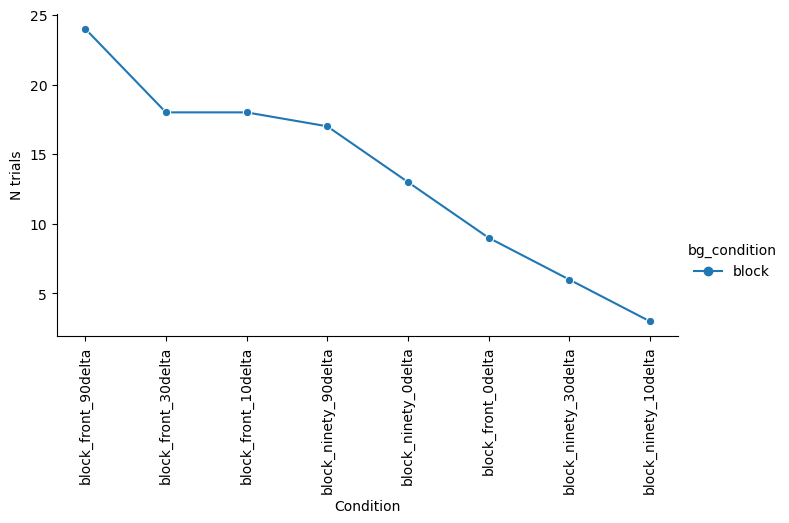

In [114]:
count_df = split_half_df.condition.value_counts().reset_index()
# count_df
# count_df.sort_values('condition', key=lambda x: x.map(sort_key), inplace=True)
# count_df['condition'] = count_df['condition'].str.replace('stationary', 'noise')
# count_df['condition'] = count_df['condition'].str.replace('Mandarin distractor', 'Mandarin')
count_df['bg_condition'] = count_df['condition'].str.rsplit('_').str[0]
# count_df['bg_condition'] = count_df['bg_condition'].replace({'stationary':'noise',  'Mandarin distractor':'Mandarin'})
palette = util_analysis.diotic_exp_color_palette()
g = sns.relplot(data=count_df,
            x='condition',
            y='count',
            kind='line',
            hue='bg_condition',
            marker='o',
            height=4,
            aspect=1.75)

g.set_xticklabels(rotation=90)
g.set(xlabel='Condition', ylabel='N trials')

# # # add space between condition groups
# for label in g.ax.get_xticklabels():
#     label.set_color(palette[label.get_text().split('_')[0]])
